In [19]:
import numpy as np
# noinspection PyUnresolvedReferences
import matplotlib.pyplot as plt
# noinspection PyUnresolvedReferences
import cv2 as cv

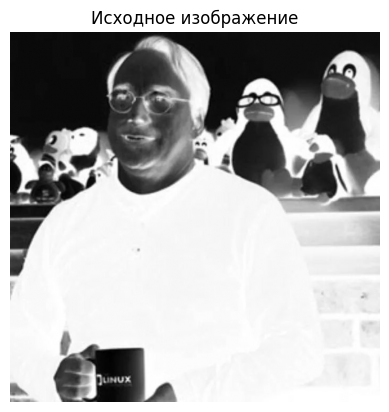

In [20]:
def load_image(path):
    image = cv.imread(path, cv.IMREAD_GRAYSCALE)
    image = image.astype(np.float32) / 255.0
    image = 1 - image
    return image

image = load_image("i.jpg")

plt.imshow(image, cmap='gray')
plt.title("Исходное изображение")
plt.axis("off")
plt.show()

In [21]:
def apply_padding(image, pad, mode="zero"):
    if pad == 0:
        return image

    if mode == "zero":
        return np.pad(image, pad, mode='constant')
    elif mode == "border":
        return np.pad(image, pad, mode='edge')
    elif mode == "mirror":
        return np.pad(image, pad, mode='reflect')
    elif mode == "cyclic":
        return np.pad(image, pad, mode='wrap')

In [22]:
def convolution(image, kernel, padding=0, stride=1, pad_mode="zero"):
    image_padded = apply_padding(image, padding, pad_mode)

    h, w = image_padded.shape
    kh, kw = kernel.shape

    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1

    output = np.zeros((out_h, out_w))

    for i in range(0, out_h):
        for j in range(0, out_w):
            region = image_padded[i*stride:i*stride+kh, j*stride:j*stride+kw]
            output[i, j] = np.sum(region * kernel)

    return output

In [23]:
def box_filter(k):
    return np.ones((k, k)) / (k * k)

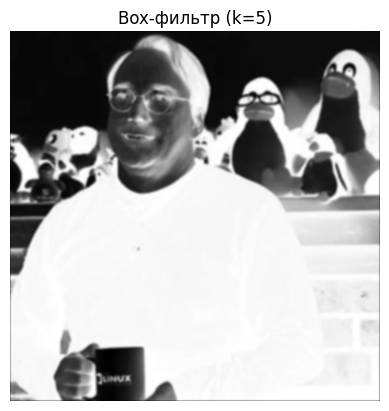

In [24]:
kernel = box_filter(5)

filtered = convolution(image, kernel, padding=2, stride=1)

plt.imshow(filtered, cmap='gray')
plt.title("Box-фильтр (k=5)")
plt.axis("off")
plt.show()

In [25]:
def gaussian_kernel(k, sigma):
    ax = np.linspace(-(k // 2), k // 2, k)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

In [26]:
def laplacian_of_gaussian(k, sigma):
    ax = np.linspace(-(k // 2), k // 2, k)
    xx, yy = np.meshgrid(ax, ax)

    norm = (xx**2 + yy**2 - 2*sigma**2) / (sigma**4)
    kernel = norm * np.exp(-(xx**2 + yy**2) / (2*sigma**2))

    return kernel - np.mean(kernel)

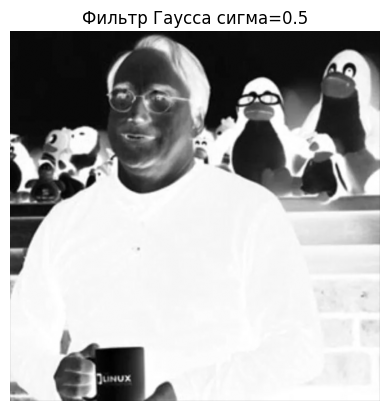

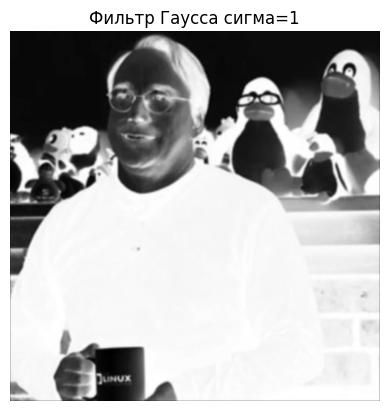

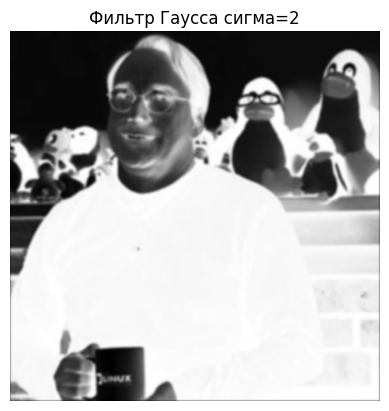

In [27]:
for sigma in [0.5, 1, 2]:
    kernel = gaussian_kernel(7, sigma)
    filtered = convolution(image, kernel, padding=3)

    plt.imshow(filtered, cmap='gray')
    plt.title(f"Фильтр Гаусса сигма={sigma}")
    plt.axis("off")
    plt.show()

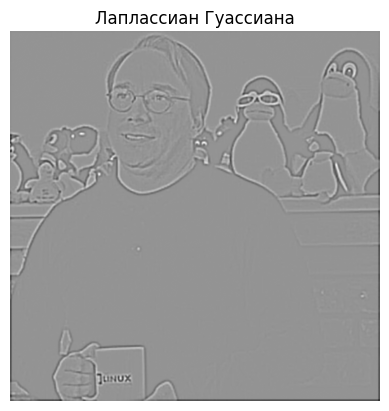

In [28]:
kernel = laplacian_of_gaussian(9, 1.5)
sharpened = convolution(image, kernel, padding=4)

plt.imshow(sharpened, cmap='gray')
plt.title("Лаплассиан Гуассиана")
plt.axis("off")
plt.show()

In [29]:
def add_gaussian_noise(image, mean=0, std=0.1):
    noise = np.random.normal(mean, std, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 1)

def add_salt_pepper_noise(image, amount=0.05):
    noisy = image.copy()
    num_pixels = int(amount * image.size)

    coords = np.random.randint(0, image.shape[0], num_pixels), \
             np.random.randint(0, image.shape[1], num_pixels)

    noisy[coords] = np.random.choice([0, 1], num_pixels)
    return noisy

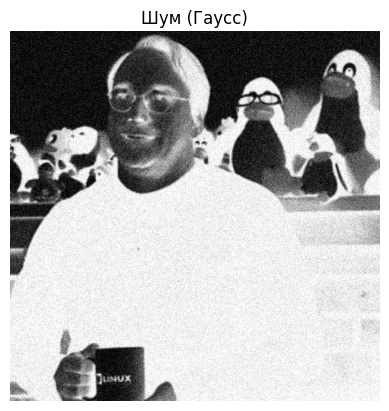

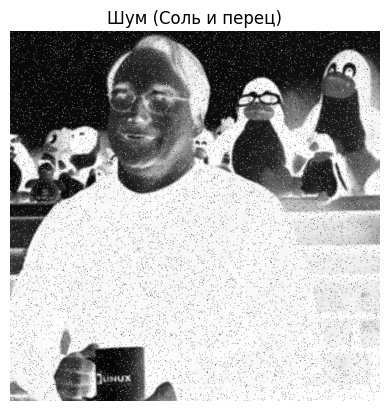

In [30]:
gaussian_noise_img = add_gaussian_noise(image)
sp_noise_img = add_salt_pepper_noise(image)

plt.imshow(gaussian_noise_img, cmap='gray')
plt.title("Шум (Гаусс)")
plt.axis("off")
plt.show()

plt.imshow(sp_noise_img, cmap='gray')
plt.title("Шум (Соль и перец)")
plt.axis("off")
plt.show()

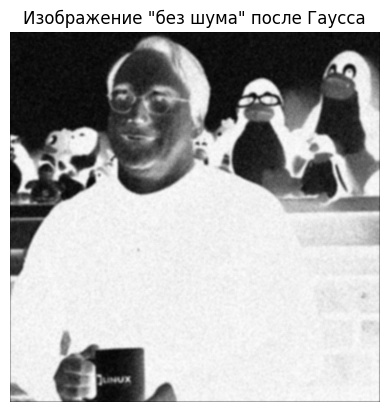

In [31]:
kernel = box_filter(5)

denoised = convolution(gaussian_noise_img, kernel, padding=2)

plt.imshow(denoised, cmap='gray')
plt.title('Изображение "без шума" после Гаусса')
plt.axis("off")
plt.show()

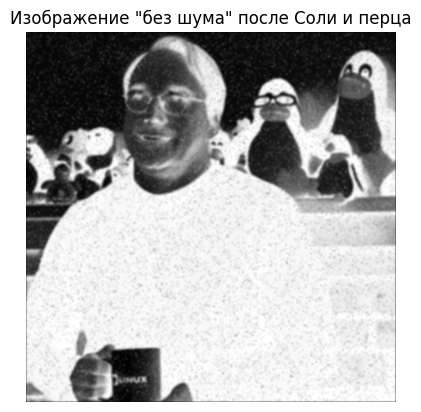

In [32]:
denoised_sp = convolution(sp_noise_img, box_filter(5), padding=2)

plt.imshow(denoised_sp, cmap='gray')
plt.title('Изображение "без шума" после Соли и перца')
plt.axis("off")
plt.show()

In [33]:
filtered_valid = convolution(image, box_filter(5), padding=0)
filtered_same = convolution(image, box_filter(5), padding=2)

print("Без padding:", filtered_valid.shape)
print("С padding:", filtered_same.shape)

Без padding: (696, 696)
С padding: (700, 700)


Сдвиг ядра 1, Размер изображения: (700, 700)


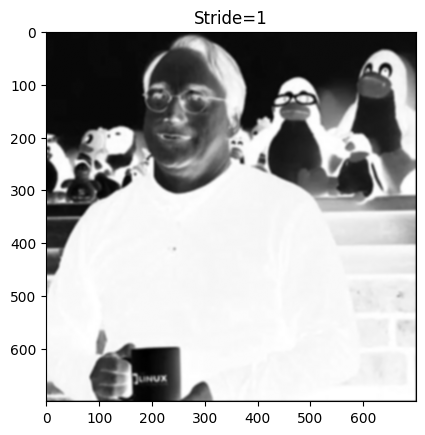

Сдвиг ядра 2, Размер изображения: (350, 350)


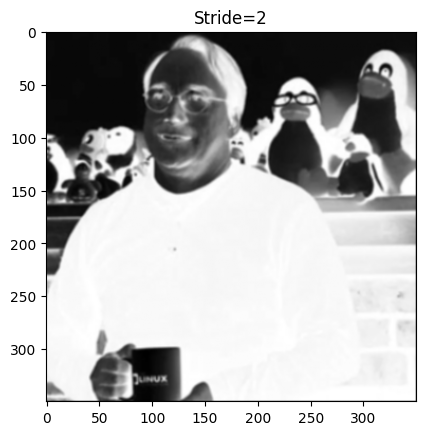

Сдвиг ядра 3, Размер изображения: (234, 234)


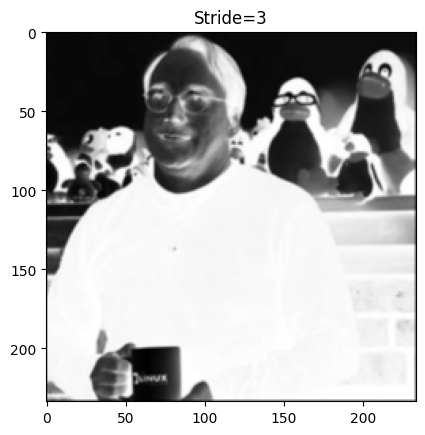

In [34]:
for stride in [1, 2, 3]:
    filtered = convolution(image, box_filter(5), padding=2, stride=stride)
    print(f"Сдвиг ядра {stride}, Размер изображения: {filtered.shape}")
    plt.imshow(filtered, cmap='gray')
    plt.title(f"Stride={stride}")
    plt.show()